In [1]:
import pandas as pd   
import numpy as np    

In [2]:
data = pd.read_csv("./data/data_cleaned/Processed_augmented_5000.csv")
df = pd.DataFrame(data)
df.head()

,Age,Gender,University,Department,Academic_Year,Current_CGPA,waiver_or_scholarship,PSS1,PSS2,PSS3,...,PHQ9,Depression Value,Depression Label,Financial_Debtor_proxy,Tuition_UpToDate_proxy,Parental_SES_proxy,Economic_Vulnerability_Index,Dropout_Risk_Score,Target_Dropout_Binary,Target_Dropout_Class
0,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,3,2,...,2,15,Moderately Severe Depression,Yes,Yes,Employe_technicien,2,0.497625,0,Low Risk
1,23-26,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3,3,2,...,2,17,Severe Depression,Yes,Yes,Ouvrier_metier_manuel,2,0.575137,1,High Risk
2,18-22,Male,Rajshahi University (RU),Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,Yes,2,4,3,...,0,15,Moderately Severe Depression,Yes,Yes,Employe_technicien,1,0.450375,0,Low Risk
3,23-26,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,2.50 - 2.99,No,4,2,3,...,3,25,Moderately Severe Depression,No,No,Employe_technicien,2,0.657038,1,High Risk
4,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,3.40 - 3.79,No,3,2,1,...,0,13,Moderately Severe Depression,Yes,Yes,Employe_technicien,1,0.466640,0,Low Risk


In [3]:
# Colonne responsable de fuite de données (data leakage) : c'est le score continu
# à partir duquel Target_Dropout_Binary / Target_Dropout_Class ont été calculés.
# On la retire dès maintenant, avant toute autre étape.
leakage_col = ['Dropout_Risk_Score']
df = df.drop(leakage_col, axis=1)

# Séparation Train / Test 



In [4]:
from sklearn.model_selection import train_test_split, cross_val_score  

# Colonnes cibles possibles (binaire et multi-classe) : on ne garde que la version binaire comme Y
target_col = ['Target_Dropout_Binary', 'Target_Dropout_Class']

X = df.drop(columns=target_col)
# Définition de la variable cible Y : la version binaire du décrochage (0 = non, 1 = oui)
Y = df['Target_Dropout_Binary']

# Contrôle des dimensions de X et Y
print("X :", X.shape)
print("Y :", Y.shape)

# Séparation des données en un jeu d'entraînement (80%) et un jeu de test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

X : (6000, 43)
Y : (6000,)


## 1. Exploration et nettoyage 

In [5]:
# Sélection des colonnes de type objet/catégoriel (texte, catégories) sur X_train
# -> nécessaire pour identifier plus tard les colonnes à encoder numériquement
categorical_col = X_train.select_dtypes(include=['object', 'category'])
categorical_list = categorical_col.columns.tolist()
categorical_list

['Age',
 'Gender',
 'University',
 'Department',
 'Academic_Year',
 'Current_CGPA',
 'waiver_or_scholarship',
 'Stress Label',
 'Anxiety Label',
 'Depression Label',
 'Financial_Debtor_proxy',
 'Tuition_UpToDate_proxy',
 'Parental_SES_proxy']

## La variable `Current_CGPA` est sous forme d'intervalle : on la convertit en nombre exact, de type numérique

In [6]:
import re  # module d'expressions régulières, utilisé pour extraire les nombres dans les chaînes de texte

def clean_cgpa(val):
    if pd.isna(val):
        # Si la valeur est déjà manquante (NaN), on la laisse telle quelle
        return np.nan

    val = str(val).strip()  # conversion en chaîne de caractères + suppression des espaces superflus

    if " - " in val:
        # Cas d'un intervalle "borne_basse - borne_haute" : on prend la moyenne des deux bornes
        low, high = map(float, val.split(" - "))
        return (low + high) / 2

    if "Bellow" in val or "<" in val:
        # Cas d'une borne ouverte vers le bas (ex: "Bellow 2.0") : on extrait le nombre
        # et on retranche 0.25 pour représenter une valeur légèrement inférieure à la borne
        num = float(re.findall(r"\d+\.\d+|\d+", val)[0])
        return num - 0.25

    if "Above" in val or ">" in val:
        # Cas d'une borne ouverte vers le haut (ex: "Above 3.5") : on extrait le nombre
        num = float(re.findall(r"\d+\.\d+|\d+", val)[0])
        return num + 0.25

    try:
        # Cas général : la valeur est déjà un nombre exploitable tel quel
        return float(val)
    except ValueError:
        # Si aucun format connu ne correspond, on renvoie NaN (valeur manquante)
        return np.nan

# ------------------------------------------------------------
# Fonction de nettoyage de la colonne 'Age'
# Cette colonne peut contenir des intervalles texte (ex: "18-25") ou des nombres entiers.
# Elle aussi est purement déterministe, applicable séparément à train et test.
# ------------------------------------------------------------
def clean_age(val):
    val = str(val).strip()  # conversion en chaîne + suppression des espaces
    if "-" in val:
        # Cas d'un intervalle "âge_min-âge_max" : on prend la moyenne des deux bornes
        low, high = map(int, val.split("-"))
        return (low + high) / 2

    try:
        # Cas général : la valeur est déjà un entier exploitable tel quel
        return int(val)
    except ValueError:
        # Si la conversion échoue (format inconnu), on renvoie NaN
        return np.nan

# Application séparée sur X_train et X_test (aucun paramètre n'est appris sur les données,
# donc aucun risque de fuite même si les DEUX jeux sont nettoyés avec les mêmes fonctions)
for _df in (X_train, X_test):
    _df["Age"] = _df["Age"].apply(clean_age)
    _df["Current_CGPA"] = _df["Current_CGPA"].apply(clean_cgpa)

X_train[["Age", "Current_CGPA"]].head()

,Age,Current_CGPA
2364,28.5,3.195
4726,20.0,2.745
1159,20.0,2.745
996,20.0,2.745
2810,24.5,3.195


## Correction des scores de santé mentale (`Stress Value`, `Anxiety Value`, `Depression Value`)

Certains scores peuvent être négatifs suite à l'agrégation des données ; on les recale à zéro par un simple décalage (shift). **Le décalage (minimum) est calculé uniquement sur `X_train`**, puis appliqué tel quel à `X_test`, afin de ne pas laisser la distribution du jeu de test influencer la transformation.

In [7]:
# Identification des colonnes concernées
mental_health_cols = ['Stress Value', 'Anxiety Value', 'Depression Value']

def fit_shift(df_train, columns):
    """Apprend, pour chaque colonne, le décalage nécessaire (|min|) à partir de X_train uniquement."""
    shifts = {}
    for col in columns:
        min_val = df_train[col].min()
        shifts[col] = -min_val if min_val < 0 else 0.0
    return shifts

def apply_shift(df_, columns, shifts):
    """Applique un décalage déjà appris (sur X_train) à n'importe quel jeu de données."""
    df_ = df_.copy()
    for col in columns:
        if shifts[col] != 0.0:
            df_[col] = df_[col] + shifts[col]
    return df_

# Apprentissage du décalage UNIQUEMENT sur X_train
mental_health_shifts = fit_shift(X_train, mental_health_cols)
print("Décalages appris sur X_train :", mental_health_shifts)

# Application du même décalage (appris sur train) à X_train et X_test
X_train = apply_shift(X_train, mental_health_cols, mental_health_shifts)
X_test = apply_shift(X_test, mental_health_cols, mental_health_shifts)

# Vérification
print("\nValeurs après shift (X_train) :")
print(X_train[mental_health_cols].describe())

Décalages appris sur X_train : {'Stress Value': 5, 'Anxiety Value': 6, 'Depression Value': 7}

Valeurs après shift (X_train) :
       Stress Value  Anxiety Value  Depression Value
count   4800.000000    4800.000000       4800.000000
mean      30.579167      21.391250         22.828750
std        8.275723       6.386085          7.485671
min        0.000000       0.000000          0.000000
25%       25.000000      17.000000         17.000000
50%       30.000000      23.000000         23.000000
75%       36.000000      27.000000         28.000000
max       54.000000      32.000000         41.000000


In [8]:
# Regroupement par 'Anxiety Label' (catégorie textuelle du niveau d'anxiété)
# et calcul du min/max de 'Anxiety Value' (score numérique GAD-7) pour chaque catégorie
# -> permet de vérifier la cohérence entre le label textuel et le score numérique associé
# (contrôle réalisé sur X_train uniquement)
print(X_train.groupby('Anxiety Label')['Anxiety Value'].agg(['min', 'max']))
print()
print(X_train.groupby('Depression Label')['Depression Value'].agg(['min', 'max']))
print()
print(X_train.groupby('Stress Label')['Stress Value'].agg(['min', 'max']))

                  min  max
Anxiety Label             
Mild Anxiety        0   31
Minimal Anxiety     0   26
Moderate Anxiety    2   31
Severe Anxiety      1   32

                              min  max
Depression Label                      
Mild Depression                 0   41
Minimal Depression              0   39
Moderate Depression             3   40
Moderately Severe Depression    3   41
No Depression                   5   40
Severe Depression               6   41

                       min  max
Stress Label                   
High Perceived Stress    9   54
Low Stress               5   50
Moderate Stress          0   54


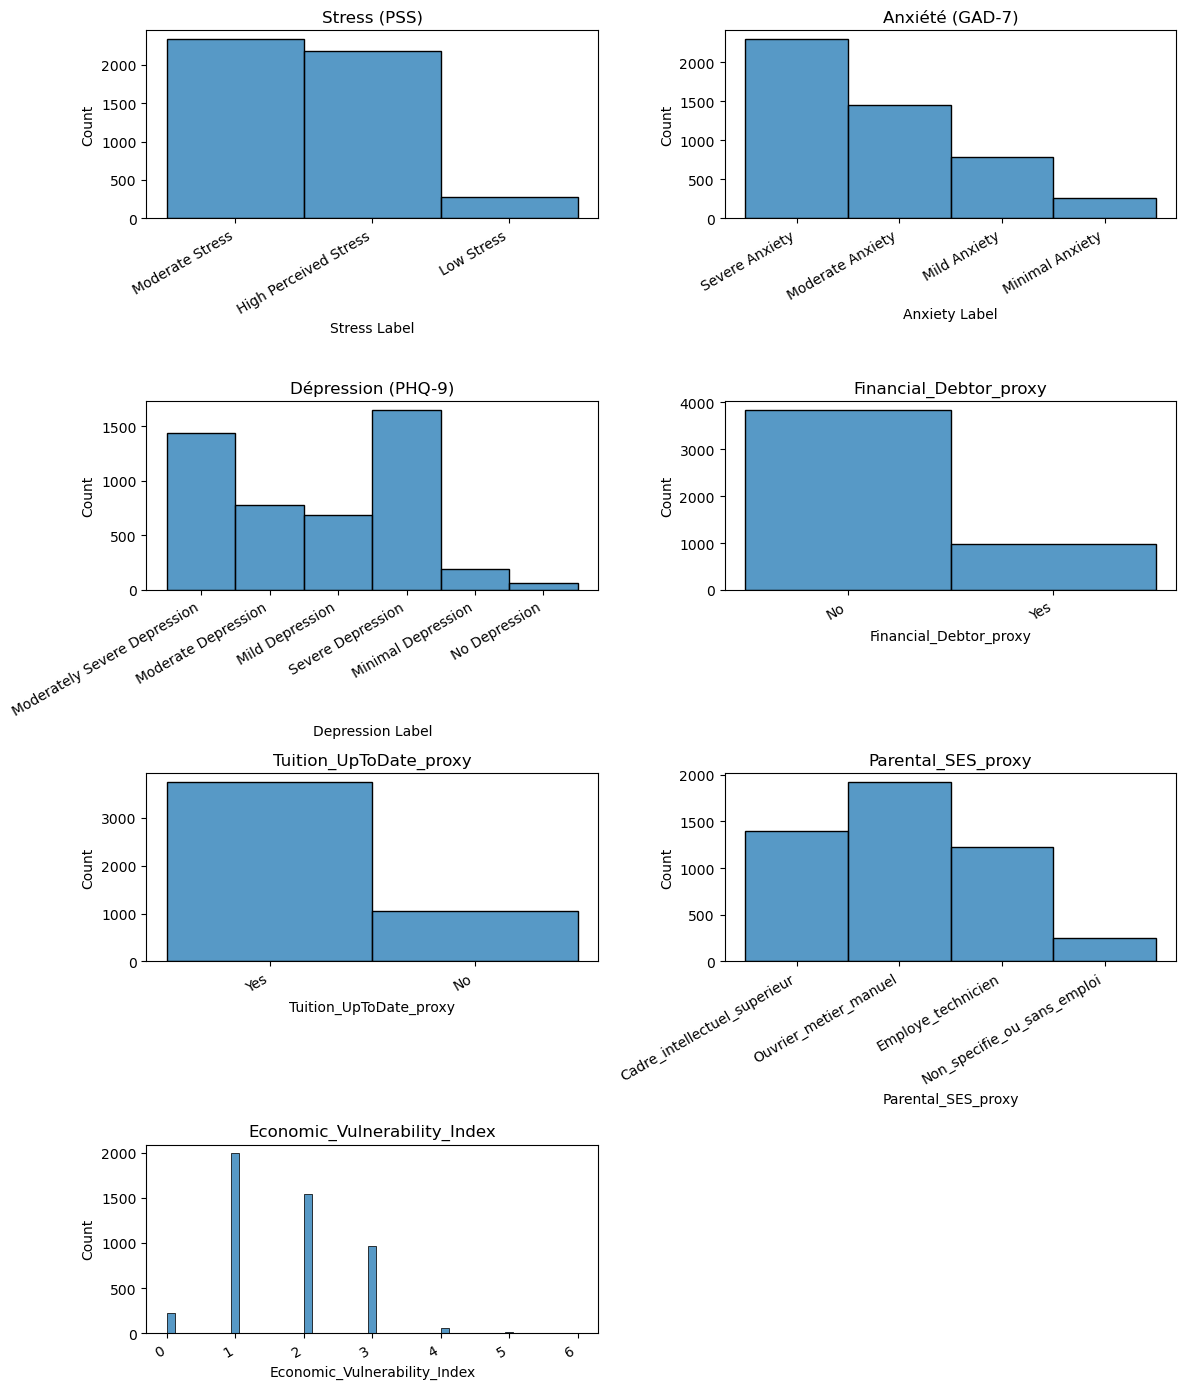

In [9]:
import matplotlib.pyplot as plt  # bibliothèque de visualisation de base
import seaborn as sns             # bibliothèque de visualisation statistique, basée sur matplotlib

# Liste des colonnes à explorer visuellement via des histogrammes (sur X_train uniquement)
cross_col = ['Stress Label', 'Anxiety Label', 'Depression Label', 'Financial_Debtor_proxy',
             'Tuition_UpToDate_proxy', 'Parental_SES_proxy', 'Economic_Vulnerability_Index']

# Création d'une grille de 4 lignes x 2 colonnes de sous-graphiques (8 emplacements, 7 utilisés)
# Augmentation légère de la hauteur (14 au lieu de 12) pour donner plus d'espace aux étiquettes inclinées
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

sns.histplot(X_train["Stress Label"], ax=axes[0][0]); axes[0][0].set_title("Stress (PSS)")
sns.histplot(X_train["Anxiety Label"], ax=axes[0][1]); axes[0][1].set_title("Anxiété (GAD-7)")
sns.histplot(X_train["Depression Label"], ax=axes[1][0]); axes[1][0].set_title("Dépression (PHQ-9)")
sns.histplot(X_train["Financial_Debtor_proxy"], ax=axes[1][1]); axes[1][1].set_title("Financial_Debtor_proxy")
sns.histplot(X_train["Tuition_UpToDate_proxy"], ax=axes[2][0]); axes[2][0].set_title("Tuition_UpToDate_proxy")
sns.histplot(X_train["Parental_SES_proxy"], ax=axes[2][1]); axes[2][1].set_title("Parental_SES_proxy")
sns.histplot(X_train["Economic_Vulnerability_Index"], ax=axes[3][0]); axes[3][0].set_title("Economic_Vulnerability_Index")
axes[3][1].axis("off")

# Appliquer la rotation et l'alignement sur l'ensemble des sous-graphiques
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

# Ajuster automatiquement les espacements et marges entre les sous-graphiques
plt.tight_layout()

# Sauvegarder la figure APRÈS tight_layout
plt.savefig("./images/exploration_variable.png", dpi=300, bbox_inches="tight")

plt.show()

## Encodage des variables catégorielles

L'encodeur (`LabelEncoder`) est **ajusté (`fit`) uniquement sur `X_train`**. Le jeu de test est ensuite transformé avec ce même encodeur : toute catégorie présente dans `X_test` mais jamais vue dans `X_train` est signalée puis encodée à `-1` (au lieu de faire planter le pipeline ou, pire, de laisser l'encodeur « apprendre » des catégories du test).

In [10]:
from sklearn.preprocessing import LabelEncoder  # encodeur qui transforme des catégories texte en entiers

# Ré-identification des colonnes catégorielles sur X_train (schéma identique à X_test)
categorical_col = X_train.select_dtypes(include=['object', 'category'])
categorical_list = categorical_col.columns.tolist()

encoders = {}  # on conserve chaque encodeur pour audit / réutilisation éventuelle (ex: API de scoring)

for col in categorical_list:
    le = LabelEncoder()
    # Apprentissage + transformation UNIQUEMENT sur X_train
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    encoders[col] = le

    # Transformation de X_test avec le même encodeur (pas de nouveau fit !)
    mapping = {cls: code for code, cls in enumerate(le.classes_)}
    unseen_mask = ~X_test[col].astype(str).isin(mapping.keys())
    if unseen_mask.any():
        print(f"[Attention] {unseen_mask.sum()} valeur(s) inédite(s) dans '{col}' (X_test) "
              f"-> encodées à -1 (jamais vues dans X_train)")
    X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)

print("Colonnes catégorielles encodées :", categorical_list)

Colonnes catégorielles encodées : ['Gender', 'University', 'Department', 'Academic_Year', 'waiver_or_scholarship', 'Stress Label', 'Anxiety Label', 'Depression Label', 'Financial_Debtor_proxy', 'Tuition_UpToDate_proxy', 'Parental_SES_proxy']


## Corrélation entre variables numériques clés (calculée sur `X_train` uniquement)

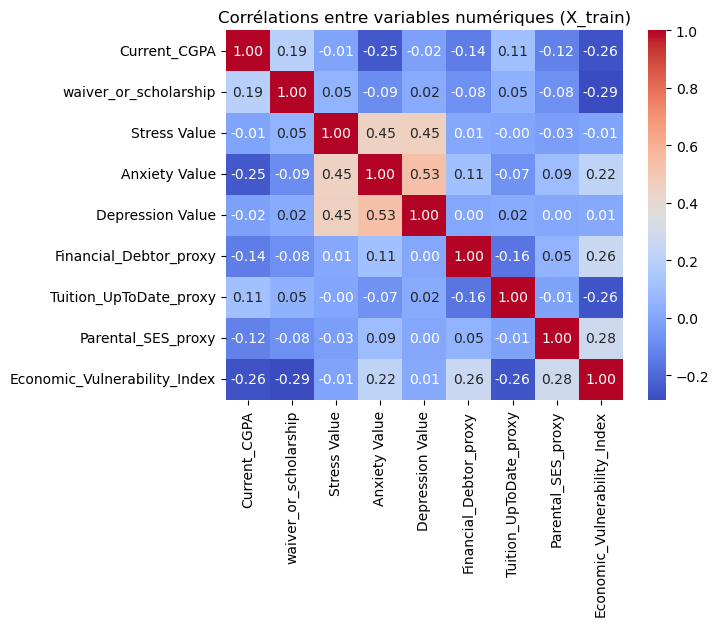

In [11]:
# Calcul de la matrice de corrélation entre quelques variables numériques clés
# (CGPA, bourse, scores de santé mentale, indicateurs socio-économiques)
# -> calculée UNIQUEMENT sur X_train, pour ne jamais laisser le test influencer l'analyse
correlation = X_train[['Current_CGPA', 'waiver_or_scholarship', 'Stress Value', 'Anxiety Value',
                        'Depression Value', 'Financial_Debtor_proxy', 'Tuition_UpToDate_proxy',
                        'Parental_SES_proxy', 'Economic_Vulnerability_Index']].corr()
plt.figure()
sns.heatmap(correlation, cmap="coolwarm", annot=True, fmt='.2f')
plt.title("Corrélations entre variables numériques (X_train)")
plt.savefig("./images/correlation.png", dpi=300, bbox_inches="tight")

plt.show()

## 🔎 Détection de fuite de données (analyse rapide)

Avant d'entraîner les modèles, on vérifie qu'**aucune variable restante n'est anormalement corrélée avec la cible** `Target_Dropout_Binary`. Une corrélation linéaire très élevée (proche de 1 en valeur absolue), ou une variable qui capte à elle seule une part disproportionnée de l'importance du modèle, est le signe typique d'une fuite de donnée résiduelle (ou d'une variable quasi-déterministe de la cible) et explique un AUC anormalement élevé (~0.99).

Ce calcul est réalisé **uniquement sur `X_train` / `y_train`**.

Corrélation de chaque variable avec la cible (X_train / y_train), triée par |corrélation| :
Current_CGPA                   -0.580364
Anxiety Value                   0.545750
Economic_Vulnerability_Index    0.512498
GAD5                            0.499382
Anxiety Label                   0.440977
Depression Label                0.434627
GAD7                            0.429295
PSS10                           0.421682
GAD1                            0.395919
Stress Label                   -0.373191
PHQ3                            0.370638
PHQ2                            0.352632
PHQ6                            0.337214
GAD6                            0.334938
PHQ7                            0.329450
PSS2                            0.327195
GAD4                            0.324793
PHQ5                            0.323820
PHQ8                            0.316434
GAD3                            0.311614
PHQ4                            0.307364
Financial_Debtor_proxy          0.285436
waiver

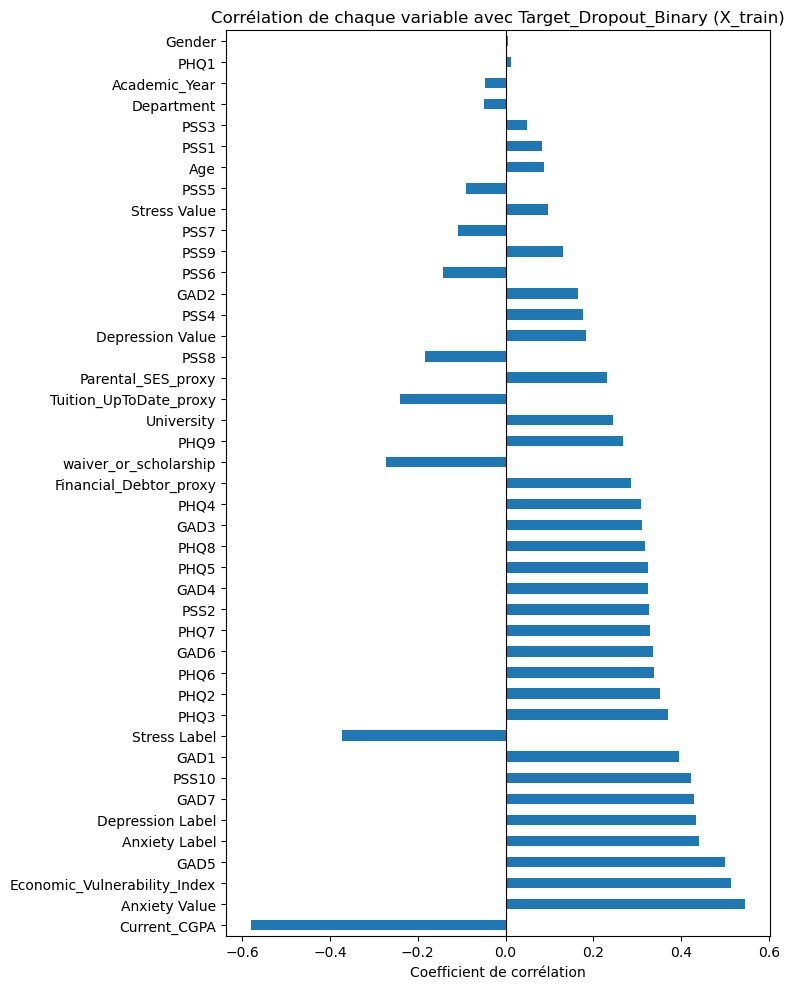

In [12]:
# --- 1) Corrélation de chaque variable numérique/encodée avec la cible (train uniquement) ---
train_with_target = X_train.select_dtypes(include=[np.number]).copy()
train_with_target["Target_Dropout_Binary"] = y_train.values

corr_with_target = (
    train_with_target.corr(numeric_only=True)["Target_Dropout_Binary"]
    .drop("Target_Dropout_Binary")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Corrélation de chaque variable avec la cible (X_train / y_train), triée par |corrélation| :")
print(corr_with_target)

CORR_THRESHOLD = 0.8
suspects_corr = corr_with_target[corr_with_target.abs() > CORR_THRESHOLD]
if not suspects_corr.empty:
    print(f"\n⚠️ Variable(s) suspectes (|corrélation| > {CORR_THRESHOLD}) — à vérifier pour fuite de données :")
    print(suspects_corr)
else:
    print(f"\nAucune variable n'a une corrélation > {CORR_THRESHOLD} avec la cible "
          "(pas de fuite évidente détectée via la corrélation linéaire).")

plt.figure(figsize=(8, 10))
corr_with_target.plot(kind="barh")
plt.title("Corrélation de chaque variable avec Target_Dropout_Binary (X_train)")
plt.xlabel("Coefficient de corrélation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("./images/correlation_cible.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. Préparation finale (imputation / mise à l'échelle)

**Constat sur `X_train` :**
- Toutes les colonnes catégorielles ont déjà été encodées (fit sur `X_train` uniquement) → pas besoin d'encodage supplémentaire.
- Les fonctions `clean_age` et `clean_cgpa` ne couvrent pas tous les formats de texte présents (ex : `"Below 18"`, `"Above 30"`, `"Other"`), ce qui laisse des valeurs manquantes (`NaN`) dans `Age` et `Current_CGPA`. On les impute avec la **médiane, apprise uniquement sur `X_train`**, puis appliquée à `X_test` (pas de fuite de données).
- Les modèles retenus (Random Forest, XGBoost) sont des ensembles d'arbres : ils sont **insensibles à l'échelle** des variables, donc un `StandardScaler` n'est pas strictement nécessaire pour la performance. On l'ajoute néanmoins ici de façon optionnelle (utile si vous testez plus tard un modèle linéaire ou une SVM), toujours `fit` sur `X_train` puis `transform` sur `X_test`.

In [13]:
X_train.isna().sum()

Age                              17
Gender                            0
University                        0
Department                        0
Academic_Year                     0
Current_CGPA                    966
waiver_or_scholarship             0
PSS1                              0
PSS2                              0
PSS3                              0
PSS4                              0
PSS5                              0
PSS6                              0
PSS7                              0
PSS8                              0
PSS9                              0
PSS10                             0
Stress Value                      0
Stress Label                      0
GAD1                              0
GAD2                              0
GAD3                              0
GAD4                              0
GAD5                              0
GAD6                              0
GAD7                              0
Anxiety Value                     0
Anxiety Label               

In [14]:
from sklearn.impute import SimpleImputer      # pour imputer (remplacer) les valeurs manquantes
from sklearn.preprocessing import StandardScaler  # pour standardiser les variables numériques

# --- Imputation des valeurs manquantes (Age, Current_CGPA) ---
# Identification des colonnes de X_train qui contiennent encore des NaN
cols_with_na = X_train.columns[X_train.isna().any()].tolist()
print("Colonnes avec valeurs manquantes :", cols_with_na)

# Création de l'imputer : remplace chaque valeur manquante par la médiane de la colonne
imputer = SimpleImputer(strategy='median')
# Copies de travail de X_train / X_test pour ne pas modifier les originaux
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

# Apprentissage de la médiane sur X_train UNIQUEMENT, puis application à X_train (fit_transform)
X_train_prep[cols_with_na] = imputer.fit_transform(X_train[cols_with_na])
# Application de la même médiane (apprise sur train) à X_test (transform seul, pas de fuite de données)
X_test_prep[cols_with_na] = imputer.transform(X_test[cols_with_na])

# Vérification qu'il ne reste plus aucune valeur manquante après imputation
print("NaN restants (train) :", X_train_prep.isna().sum().sum())
print("NaN restants (test)  :", X_test_prep.isna().sum().sum())

# --- Mise à l'échelle (optionnelle, gardée pour les modèles sensibles à l'échelle) ---
scaler = StandardScaler()
# Apprentissage des paramètres de mise à l'échelle sur X_train_prep UNIQUEMENT, puis transformation
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_prep),
    columns=X_train_prep.columns,
    index=X_train_prep.index
)
# Application de la même transformation (apprise sur train) à X_test_prep
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_prep),
    columns=X_test_prep.columns,
    index=X_test_prep.index
)

# Les modèles d'arbres utiliseront X_train_prep / X_test_prep (non standardisés,
# ce qui préserve aussi l'interprétabilité de la feature importance).
X_train_prep.head()

Colonnes avec valeurs manquantes : ['Age', 'Current_CGPA']
NaN restants (train) : 0
NaN restants (test)  : 0


,Age,Gender,University,Department,Academic_Year,Current_CGPA,waiver_or_scholarship,PSS1,PSS2,PSS3,...,PHQ6,PHQ7,PHQ8,PHQ9,Depression Value,Depression Label,Financial_Debtor_proxy,Tuition_UpToDate_proxy,Parental_SES_proxy,Economic_Vulnerability_Index
2364,28.5,0,10,2,4,3.195,0,0,2,4,...,2,3,3,0,18,3,0,1,0,1
4726,20.0,1,3,2,4,2.745,0,3,3,4,...,3,3,0,0,24,3,0,1,3,2
1159,20.0,1,3,2,0,2.745,0,-1,4,3,...,2,-1,2,1,24,2,1,1,1,1
996,20.0,0,3,2,0,2.745,0,1,3,3,...,2,3,3,3,36,0,0,1,0,3
2810,24.5,1,8,2,3,3.195,0,0,2,1,...,0,1,1,0,18,0,0,1,3,1


# 3. Entraînement et évaluation des modèles

On entraîne plusieurs modèles de classification pour ce problème tabulaire :
- **Régression logistique** (baseline)
- **KNN**
- **Random Forest**
- **XGBoost**

Puis on calcule les métriques clés : **Accuracy, Precision, Recall, F1-Score, AUC-ROC** — **uniquement sur le jeu de test**.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier                     # modèle d'ensemble d'arbres en boosting de gradient
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)  # métriques d'évaluation de classification


rl_model = LogisticRegression()
rl_model.fit(X_train_prep, y_train)

/home/ricardo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

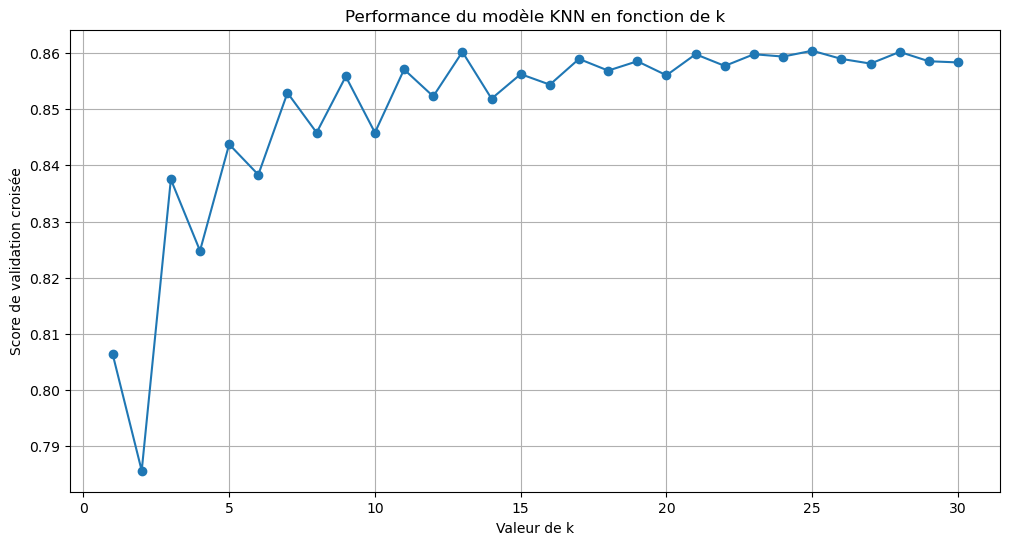

Meilleure valeur de k: 25
Meilleur score de validation croisée: 0.8604


In [16]:
k_range = range(1, 31)
k_scores = []

# La validation croisée (cross_val_score) est réalisée uniquement sur X_train_prep / y_train,
# donc entièrement à l'intérieur du jeu d'entraînement : pas de fuite depuis le test.
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_prep, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Visualisation des résultats
plt.figure(figsize=(12, 6))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Valeur de k')
plt.ylabel('Score de validation croisée')
plt.title('Performance du modèle KNN en fonction de k')
plt.grid(True)
plt.show()

# Meilleure valeur de k
best_k = k_range[np.argmax(k_scores)]
print(f"Meilleure valeur de k: {best_k}")
print(f"Meilleur score de validation croisée: {max(k_scores):.4f}")

In [17]:
knn_model = KNeighborsClassifier(n_neighbors=13)
knn_model.fit(X_train_prep, y_train)

# --- Random Forest ---
# Instanciation du modèle Random Forest :
# - n_estimators=300 : nombre d'arbres dans la forêt
# - max_depth=None : les arbres se développent jusqu'à pureté des feuilles (pas de limite de profondeur)
# - random_state=42 : reproductibilité
# - n_jobs=-1 : utilise tous les cœurs CPU disponibles pour paralléliser l'entraînement
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
# Entraînement du modèle Random Forest sur les données préparées (imputées, non standardisées)
rf_model.fit(X_train_prep, y_train)

# --- XGBoost ---
# Instanciation du modèle XGBoost (boosting de gradient) :
# - n_estimators=300 : nombre d'arbres (itérations de boosting)
# - max_depth=5 : profondeur maximale de chaque arbre
# - learning_rate=0.05 : taux d'apprentissage (pas de mise à jour à chaque itération)
# - subsample=0.9 : fraction des observations utilisées pour chaque arbre (réduit le sur-apprentissage)
# - colsample_bytree=0.9 : fraction des variables utilisées pour chaque arbre
# - eval_metric='logloss' : métrique interne utilisée pendant l'entraînement
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss'
)
# Entraînement du modèle XGBoost sur les mêmes données préparées
xgb_model.fit(X_train_prep, y_train)

# Dictionnaire regroupant les modèles entraînés, pour les évaluer/comparer facilement
models = {
    "Regression logistic": rl_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

print("Modèles entraînés :", list(models.keys()))

Modèles entraînés : ['Regression logistic', 'KNN', 'Random Forest', 'XGBoost']


## 🔎 Détection de fuite de données (suite) — importance des variables

On complète le diagnostic avec l'**importance des variables** (`feature_importances_`) des modèles à base d'arbres. Si une seule variable domine très largement (par exemple > 30% de l'importance totale) alors qu'aucune raison métier ne le justifie, c'est un indice supplémentaire de fuite de données ou de variable quasi-déterministe de la cible — à croiser avec la corrélation calculée plus haut.

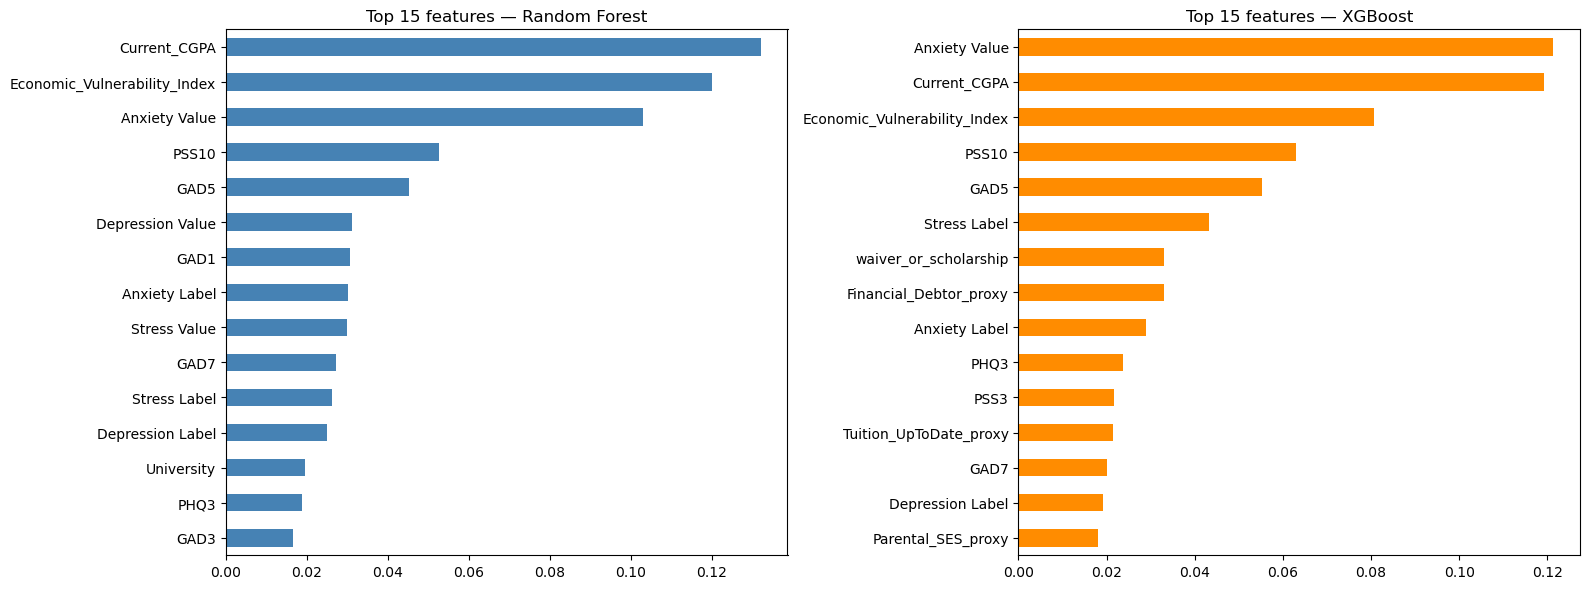

Variable la plus importante (Random Forest) : Current_CGPA (0.132)
Variable la plus importante (XGBoost)       : Anxiety Value (0.121)


In [18]:
importances_rf = pd.Series(rf_model.feature_importances_, index=X_train_prep.columns).sort_values(ascending=False)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train_prep.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
importances_rf.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title("Top 15 features — Random Forest")

importances_xgb.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title("Top 15 features — XGBoost")
plt.tight_layout()
plt.show()

print("Variable la plus importante (Random Forest) :", importances_rf.index[0], f"({importances_rf.iloc[0]:.3f})")
print("Variable la plus importante (XGBoost)       :", importances_xgb.index[0], f"({importances_xgb.iloc[0]:.3f})")

IMPORTANCE_THRESHOLD = 0.30
for name, imp in [("Random Forest", importances_rf), ("XGBoost", importances_xgb)]:
    if imp.iloc[0] > IMPORTANCE_THRESHOLD:
        print(f"\n⚠️ [{name}] La variable '{imp.index[0]}' domine largement l'importance "
              f"({imp.iloc[0]:.1%}) -> à vérifier : fuite de données potentielle ou "
              "variable quasi-déterministe de la cible.")

## 4. Évaluation sur le jeu de test — les métriques et courbes ROC ci-dessous sont calculées **uniquement sur `X_test` / `y_test`**

In [19]:
results = {}  # dictionnaire qui stockera, pour chaque modèle, les prédictions et les métriques

# Boucle sur chaque modèle entraîné pour l'évaluer sur le jeu de test UNIQUEMENT
for name, model in models.items():
    # Prédiction des classes (0/1) sur le jeu de test
    y_pred = model.predict(X_test_prep)
    # Prédiction des probabilités de la classe positive (décrochage=1), utile pour l'AUC-ROC
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    # Stockage des prédictions et du calcul des métriques de performance pour ce modèle
    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    }

# Construction d'un DataFrame récapitulatif des métriques (une ligne par modèle),
# en excluant les tableaux de prédictions (y_pred, y_proba) qui ne sont pas des scalaires
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ("y_pred", "y_proba")}
    for name, res in results.items()
}).T

# Arrondi des métriques à 4 décimales pour la lisibilité
metrics_df = metrics_df.round(4)
print(metrics_df)

# Affichage du rapport de classification détaillé (precision/recall/f1 par classe) pour chaque modèle
for name in models:
    print(f"\n--- Rapport de classification : {name} ---")
    print(classification_report(y_test, results[name]["y_pred"], target_names=["Non-décrochage (0)", "Décrochage (1)"]))

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regression logistic    0.9267     0.9251  0.9368    0.9309   0.9808
KNN                    0.8692     0.8980  0.8483    0.8725   0.9440
Random Forest          0.9592     0.9620  0.9605    0.9613   0.9928
XGBoost                0.9600     0.9695  0.9542    0.9618   0.9943

--- Rapport de classification : Regression logistic ---
                    precision    recall  f1-score   support

Non-décrochage (0)       0.93      0.92      0.92       567
    Décrochage (1)       0.93      0.94      0.93       633

          accuracy                           0.93      1200
         macro avg       0.93      0.93      0.93      1200
      weighted avg       0.93      0.93      0.93      1200


--- Rapport de classification : KNN ---
                    precision    recall  f1-score   support

Non-décrochage (0)       0.84      0.89      0.87       567
    Décrochage (1)       0.90      0.85      0.87       633

          accurac

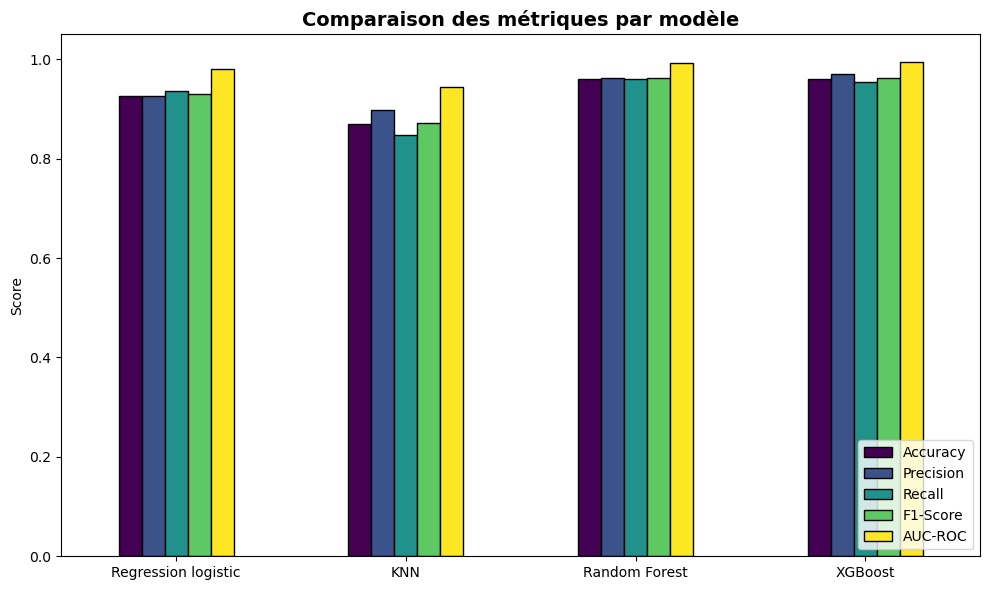

In [21]:
# Diagramme en barres comparant les 5 métriques (Accuracy, Precision, Recall, F1, AUC-ROC)
# entre les différents modèles, pour une comparaison visuelle rapide
metrics_df[["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis", edgecolor="black"
)
plt.title("Comparaison des métriques par modèle", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./images/metrique_models.png", dpi=300, bbox_inches="tight")

plt.show()

# 5. Visualisations avancées\n\n## 5.1 Matrices de confusion (Heatmap)

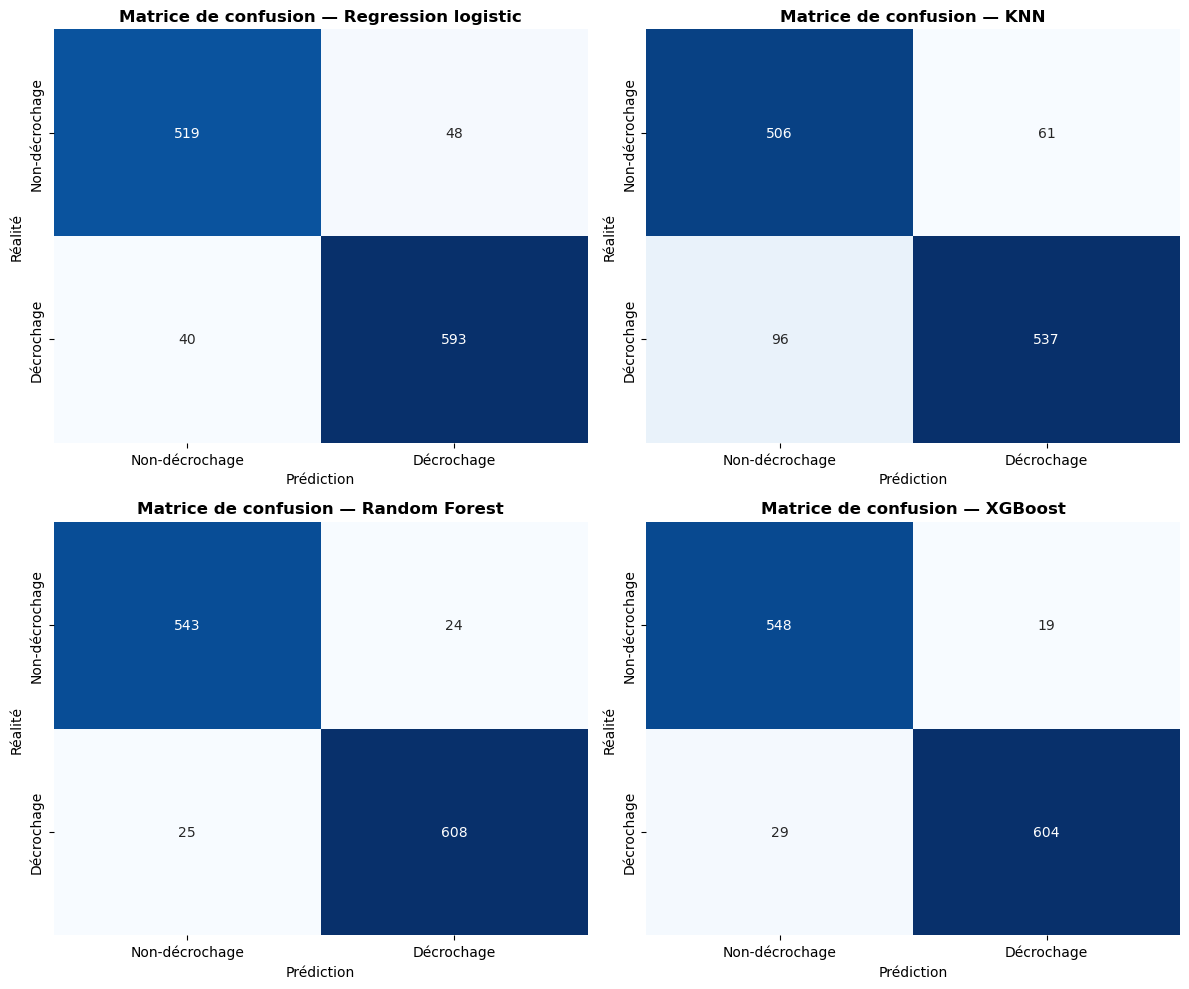

In [24]:
# Création d'une figure avec une grille 2x2 pour les 4 matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Aplatir la grille (2, 2) en une liste de 4 axes
axes = axes.flatten()

# Boucle sur chaque modèle et son axe correspondant
for ax, (name, res) in zip(axes, results.items()):
    # Calcul de la matrice de confusion (vrais/faux positifs/négatifs) pour ce modèle, sur le TEST
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Non-décrochage", "Décrochage"],
        yticklabels=["Non-décrochage", "Décrochage"]
    )
    ax.set_title(f"Matrice de confusion — {name}", fontweight="bold")
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")

plt.tight_layout()
plt.savefig("./images/matrice_de_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.2 Courbes ROC comparatives (jeu de test uniquement)

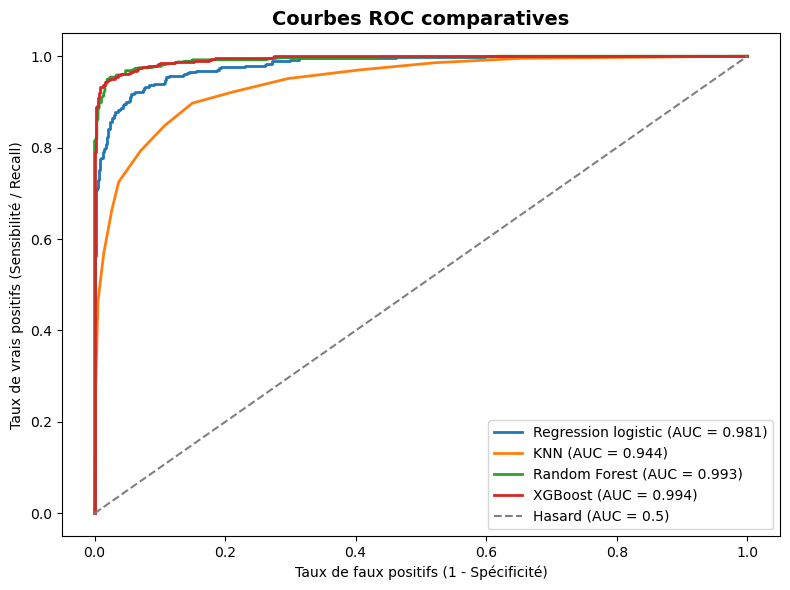

In [26]:
plt.figure(figsize=(8, 6))

# Pour chaque modèle, on trace sa courbe ROC (taux de vrais positifs vs taux de faux positifs)
# calculée exclusivement à partir de y_test / y_proba (jeu de test)
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc = res["AUC-ROC"]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

# Ligne diagonale de référence représentant un classifieur aléatoire (AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Sensibilité / Recall)")
plt.title("Courbes ROC comparatives", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5.3 Analyses croisées : santé mentale / CGPA vs risque de décrochage prédit

On utilise les prédictions du modèle **XGBoost** (au choix, les autres modèles donnent des résultats proches) sur le jeu de test pour explorer comment le CGPA et les indicateurs de santé mentale se répartissent selon le risque de décrochage prédit.

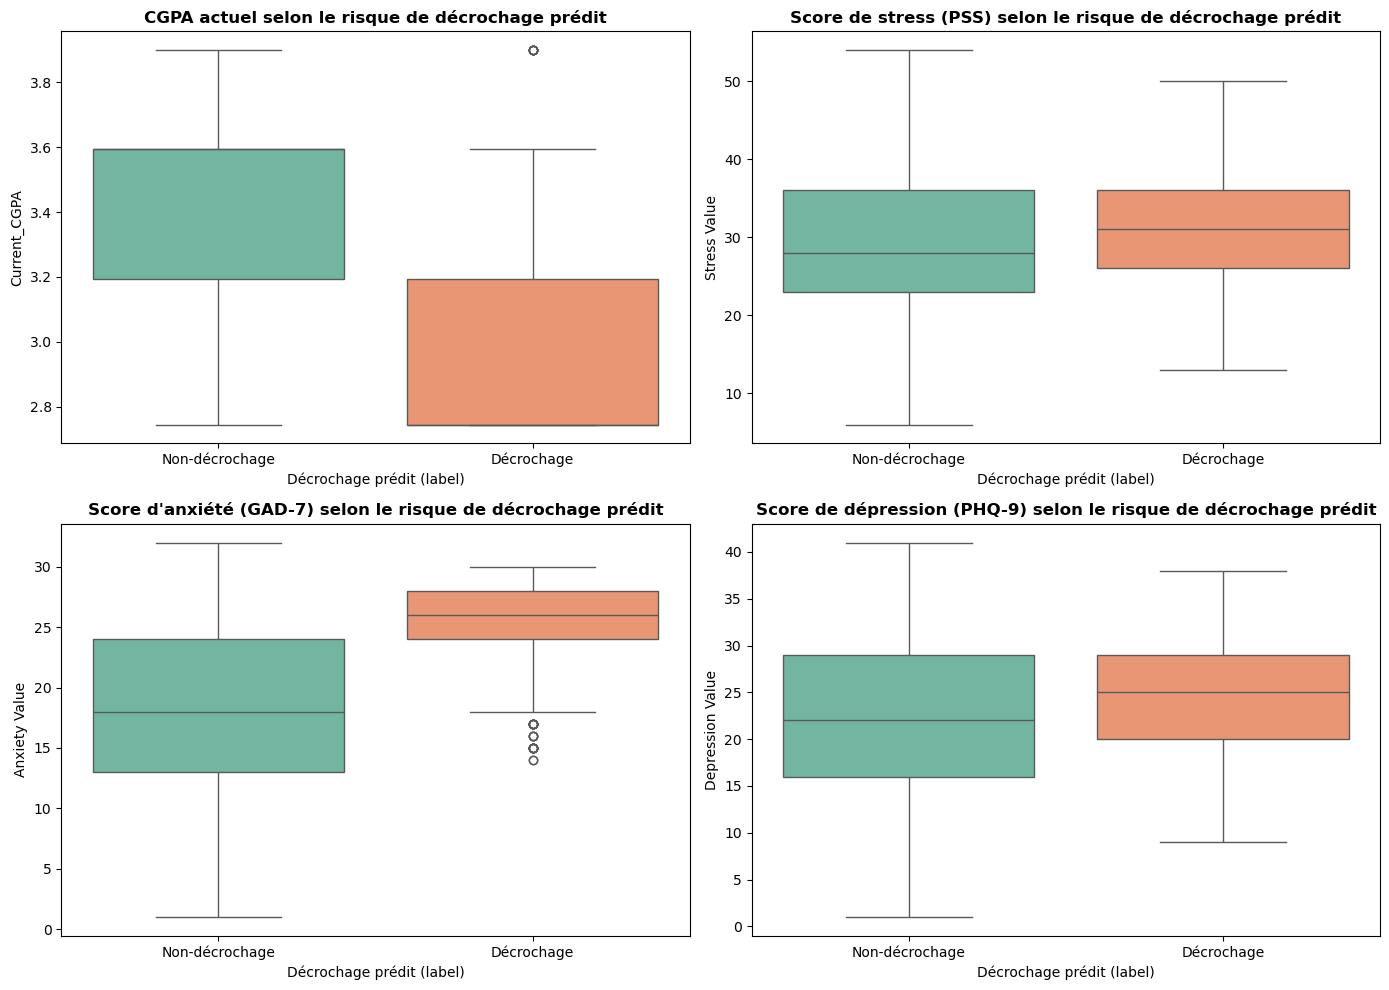

In [27]:
# On repart des lignes du jeu de test (non standardisées) pour garder les valeurs interprétables
analysis_df = X_test.copy()
# Ajout de la vraie valeur cible (décrochage réel) pour comparaison
analysis_df["Décrochage réel"] = y_test.values
# Ajout de la prédiction du modèle XGBoost (0/1)
analysis_df["Décrochage prédit (XGBoost)"] = results["XGBoost"]["y_pred"]
# Conversion de la prédiction numérique en label texte lisible, pour les graphiques
analysis_df["Décrochage prédit (label)"] = analysis_df["Décrochage prédit (XGBoost)"].map(
    {0: "Non-décrochage", 1: "Décrochage"}
)

# Grille de 2x2 graphiques en boîte (boxplot) pour comparer les distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=analysis_df, x="Décrochage prédit (label)", y="Current_CGPA",
            hue="Décrochage prédit (label)", palette="Set2", legend=False, ax=axes[0][0])
axes[0][0].set_title("CGPA actuel selon le risque de décrochage prédit", fontweight="bold")

sns.boxplot(data=analysis_df, x="Décrochage prédit (label)", y="Stress Value",
            hue="Décrochage prédit (label)", palette="Set2", legend=False, ax=axes[0][1])
axes[0][1].set_title("Score de stress (PSS) selon le risque de décrochage prédit", fontweight="bold")

sns.boxplot(data=analysis_df, x="Décrochage prédit (label)", y="Anxiety Value",
            hue="Décrochage prédit (label)", palette="Set2", legend=False, ax=axes[1][0])
axes[1][0].set_title("Score d'anxiété (GAD-7) selon le risque de décrochage prédit", fontweight="bold")

sns.boxplot(data=analysis_df, x="Décrochage prédit (label)", y="Depression Value",
            hue="Décrochage prédit (label)", palette="Set2", legend=False, ax=axes[1][1])
axes[1][1].set_title("Score de dépression (PHQ-9) selon le risque de décrochage prédit", fontweight="bold")

plt.savefig("./images/analyse_croisée.png", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

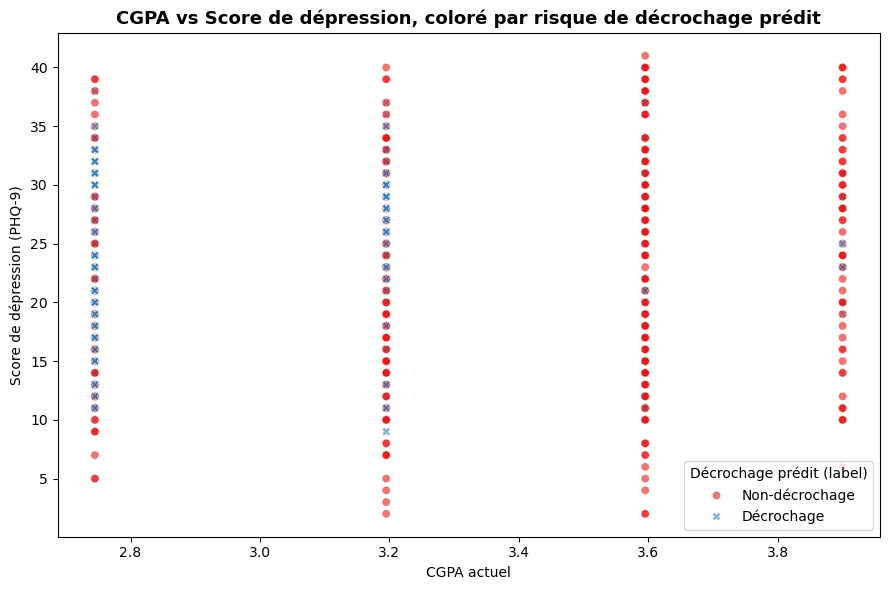

In [28]:
plt.figure(figsize=(9, 6))
# Nuage de points croisant CGPA et score de dépression, coloré/marqué selon la prédiction de décrochage
sns.scatterplot(
    data=analysis_df,
    x="Current_CGPA",
    y="Depression Value",
    hue="Décrochage prédit (label)",
    style="Décrochage prédit (label)",
    palette="Set1",
    alpha=0.6
)
plt.title("CGPA vs Score de dépression, coloré par risque de décrochage prédit", fontsize=13, fontweight="bold")
plt.xlabel("CGPA actuel")
plt.ylabel("Score de dépression (PHQ-9)")
plt.savefig("./images/relation_variable.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

# Conclusion

- Le `train_test_split` est désormais réalisé **avant** tout prétraitement (nettoyage, encodage, imputation, mise à l'échelle) : chaque transformation statistique (médiane, décalage, catégories, moyenne/écart-type) est apprise **uniquement sur `X_train`** puis appliquée à `X_test`, ce qui élimine la fuite de données liée à l'ordre des opérations.
- La colonne `Dropout_Risk_Score` (score continu ayant servi à construire la cible) reste exclue des features, comme dans la version initiale.
- La cellule de diagnostic (corrélation avec la cible + importance des variables) permet d'identifier explicitement toute variable qui expliquerait un AUC anormalement élevé, plutôt que de le constater a posteriori.
- Les scores de santé mentale (stress, anxiété, dépression) et le CGPA restent, comme attendu, parmi les variables les plus influentes, ce qui est cohérent avec la logique métier du projet MADADATA.
- Prochaines étapes possibles : validation croisée (k-fold) sur l'ensemble du pipeline (avec `Pipeline`/`ColumnTransformer` scikit-learn pour éviter tout risque de fuite lors du tuning), recherche d'hyperparamètres (GridSearchCV / Optuna), test d'autres modèles (LightGBM), et analyse de l'explicabilité au niveau individuel (SHAP).

## Export du modèle
Sélection du meilleur modèle entraîné (selon la métrique AUC-ROC, calculée uniquement sur le jeu de test, déjà stockée dans `metrics_df`) et export sous forme de fichiers `.pkl` et `.joblib` dans un dossier `artifacts/` situé à l'extérieur du dossier courant contenant ce notebook.

In [24]:
import os      # module pour manipuler les chemins et créer des dossiers
import pickle   # module standard Python pour sérialiser (sauvegarder) des objets, dont les modèles
import joblib   # bibliothèque optimisée pour la sérialisation d'objets contenant de gros tableaux numpy (modèles sklearn/xgboost)

# ------------------------------------------------------------
# 1) Sélection du "meilleur" modèle parmi ceux déjà entraînés et évalués (results / metrics_df)
#    Critère retenu : l'AUC-ROC, métrique déjà calculée plus haut dans le notebook (sur X_test),
#    car elle résume bien la capacité globale de discrimination du modèle (indépendante du seuil).
# ------------------------------------------------------------
best_model_name = metrics_df["AUC-ROC"].idxmax()  # nom du modèle ayant le meilleur AUC-ROC
best_model = models[best_model_name]                # récupération de l'objet modèle entraîné correspondant

print(f"Meilleur modèle sélectionné pour l'export : {best_model_name} "
      f"(AUC-ROC = {metrics_df.loc[best_model_name, 'AUC-ROC']})")

# ------------------------------------------------------------
# 2) Construction du chemin vers le dossier 'artifacts', situé À L'EXTÉRIEUR
#    du dossier courant contenant ce fichier .ipynb (donc un niveau au-dessus : '..')
# ------------------------------------------------------------
models_dir = os.path.abspath(os.path.join(os.getcwd(), '.', 'models'))
os.makedirs(models_dir, exist_ok=True)

# ------------------------------------------------------------
# 3) Construction des chemins complets des fichiers de sortie
# ------------------------------------------------------------
pkl_path = os.path.join(models_dir, "best_dropout_model.pkl")
joblib_path = os.path.join(models_dir, "best_dropout_model.joblib")

# ------------------------------------------------------------
# 4) Sauvegarde du modèle au format .pkl avec le module 'pickle'
# ------------------------------------------------------------
with open(pkl_path, "wb") as f:
    pickle.dump(best_model, f)

# ------------------------------------------------------------
# 5) Sauvegarde du modèle au format .joblib
# ------------------------------------------------------------
joblib.dump(best_model, joblib_path)

# Confirmation des chemins de sauvegarde pour l'utilisateur
print(f"Modèle '{best_model_name}' exporté avec succès :")
print(f" - Pickle : {pkl_path}")
print(f" - Joblib : {joblib_path}")

Meilleur modèle sélectionné pour l'export : XGBoost (AUC-ROC = 0.9943)
Modèle 'XGBoost' exporté avec succès :
 - Pickle : /home/ricardo/Documents/uniglobal_app/models/best_dropout_model.pkl
 - Joblib : /home/ricardo/Documents/uniglobal_app/models/best_dropout_model.joblib
